# Hyperparameter Tuning Using Ray Tune & Optuna

In [ ]:
import pandas as pd
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from torchinfo import summary
from torch.utils.tensorboard import SummaryWriter
import os
from datetime import datetime
from collections import Counter

from notifier import send_notification, send_image, send_email
import time
from typing import Dict, Optional, Any

import ray
from ray import tune
from ray.tune.search import ConcurrencyLimiter
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler
from ray.train import Checkpoint

In [2]:
writer = SummaryWriter()

In [3]:
with open('../data/processed/dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'mps'

In [5]:
dataset.keys()

dict_keys(['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'X_train_store_category_le', 'X_val_store_category_le', 'X_test_store_category_le', 'y_scaler', 'X_scaler'])

In [6]:
X_train = dataset['X_train'].drop(columns=["store_primary_category"], axis=1)
y_train = dataset['y_train']
X_test = dataset['X_test'].drop(columns=["store_primary_category"], axis=1)
y_test = dataset['y_test']
X_val = dataset['X_val'].drop(columns=["store_primary_category"], axis=1)
y_val = dataset['y_val']
X_train_store_category_le=dataset['X_train_store_category_le']
X_val_store_category_le=dataset['X_val_store_category_le']
X_test_store_category_le=dataset['X_test_store_category_le']
y_scaler = dataset['y_scaler']

In [7]:
len(X_train_store_category_le.unique())

66

In [8]:
X_train

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_at_day,created_at_week_of_month,...,order_protocol_4,order_protocol_5,order_protocol_6,order_protocol_7,market_id_1.0,market_id_2.0,market_id_3.0,market_id_4.0,market_id_5.0,market_id_6.0
0,-0.887847,-0.774580,-1.034172,1.175252,0.233244,0.356917,-0.239323,-0.063258,-1.134736,-1.239225,...,-0.328042,-0.551125,-0.055785,-0.010236,1.988032,-0.669426,-0.361982,-0.604066,-0.336386,-0.061526
1,0.323576,0.936110,0.203869,-0.179647,0.466436,-0.898395,-0.866322,-0.691474,0.050511,0.223960,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,-0.604066,2.972779,-0.061526
2,0.727384,0.600475,0.822890,-0.664373,0.053865,-0.985975,-1.023072,-0.938953,0.912508,0.955552,...,-0.328042,-0.551125,-0.055785,-0.010236,1.988032,-0.669426,-0.361982,-0.604066,-0.336386,-0.061526
3,-0.080232,-1.258467,0.203869,-1.151047,-1.817052,-0.927588,-1.023072,-0.938953,0.697009,0.955552,...,3.048392,-0.551125,-0.055785,-0.010236,1.988032,-0.669426,-0.361982,-0.604066,-0.336386,-0.061526
4,1.938807,1.653122,2.060932,-1.053712,-0.295923,1.115942,0.857927,1.078952,1.666756,1.687144,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,-0.604066,-0.336386,16.253271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124094,-0.080232,-0.288488,0.203869,-0.179647,-0.835852,-0.256143,-0.803622,-0.653400,1.451257,1.687144,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,1.655449,-0.336386,-0.061526
124095,-0.484040,-0.667111,-0.415151,0.007236,-0.663649,1.641422,1.798427,2.620935,1.666756,1.687144,...,-0.328042,1.814470,-0.055785,-0.010236,-0.503010,1.493818,-0.361982,-0.604066,-0.336386,-0.061526
124096,0.727384,1.802477,1.441911,-0.664373,1.348978,0.619656,0.701177,0.679178,1.235757,0.955552,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,1.655449,-0.336386,-0.061526
124097,-0.080232,-0.443905,0.203869,-0.576772,-0.609835,-0.139369,-0.490123,-0.577253,0.589259,0.223960,...,-0.328042,1.814470,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,1.655449,-0.336386,-0.061526


In [9]:
class CustomDataset(Dataset):
    def __init__(self, X, y, category):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long).unsqueeze(1)
        self.category = torch.tensor(category.values, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.category[idx]
    
train_dataset = CustomDataset(X_train, y_train, X_train_store_category_le)
val_dataset = CustomDataset(X_val, y_val, X_val_store_category_le)
test_dataset = CustomDataset(X_test, y_test, X_test_store_category_le)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
for X_batch, y_batch, category_batch in val_loader:
    print(f'X_batch shape: {X_batch.shape}, y_batch shape: {y_batch.shape}, category_batch shape: {category_batch.shape}')
    break

X_batch shape: torch.Size([64, 47]), y_batch shape: torch.Size([64, 1]), category_batch shape: torch.Size([64])


In [ ]:
class Trainer:
    def __init__(self, model, criterion, optimizer, log_dir=None, checkpoint_dir=None):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.plotting_dict = {
            "train_loss": [],
            "val_loss": [],
        }
        self.early_stop_counter = 0
        self.early_stop_patience = 5
        self.best_val_loss = float('inf')
        self.checkpoint_dir = checkpoint_dir
        
        if log_dir is None:
            current_time = datetime.now().strftime('%Y%m%d-%H%M%S')
            log_dir = os.path.join('runs', current_time)
        
        self.writer = SummaryWriter(log_dir)
    
    def train(self, train_dataloader, val_dataloader, epochs=5, checkpoint_path=None):
        self.model.train()
        dataset_size = len(train_dataloader)
        
        temp_checkpoint_dir = self.checkpoint_dir
        if temp_checkpoint_dir is None:
            temp_checkpoint_dir = os.path.abspath(os.path.join(os.getcwd(), 'ray_results'))
            os.makedirs(temp_checkpoint_dir, exist_ok=True)
        
        checkpoint = ray.train.get_checkpoint()
        if checkpoint:
            with checkpoint.as_directory() as checkpoint_dir:
                print(f"Loading checkpoint from {checkpoint_dir}")
                checkpoint_dict = torch.load(os.path.join(checkpoint_dir, "checkpoint.pt"))
                start = checkpoint_dict["epoch"] + 1
                self.model.load_state_dict(checkpoint_dict["model_state"])
        
        for epoch in range(epochs):
            total_loss = 0
            for i, (inputs, targets, category) in enumerate(train_dataloader):
                inputs, targets, category = inputs.to(device), targets.to(device), category.to(device)
                
                outputs = self.model(inputs, category)
                loss = self.criterion(outputs, targets.float())
                loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()
                
                total_loss += loss.item()
                
                if i % 10 == 0: 
                    step = epoch * len(train_dataloader) + i
                    self.writer.add_scalar('Batch/Loss', loss.item(), step)
            
            individual_loss = total_loss / dataset_size
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {individual_loss:.4f}")
            
            val_loss = self.evaluate(val_dataloader, "Validation")
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.early_stop_counter = 0
                
                print(f"Validation loss improved to {val_loss:.4f}. Saving model...")
                checkpoint_path = os.path.join(temp_checkpoint_dir, "checkpoint.pt")
                torch.save({
                    "epoch": epoch,
                    "model_state": self.model.state_dict(),
                    "optimizer_state": self.optimizer.state_dict(),
                    "val_loss": val_loss
                }, checkpoint_path)
            else:
                self.early_stop_counter += 1
                if self.early_stop_counter >= self.early_stop_patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
            
            self.plotting_dict["train_loss"].append(individual_loss)
            self.plotting_dict["val_loss"].append(val_loss)
            
            self.writer.add_scalar('Loss/Train', individual_loss, epoch)
            self.writer.add_scalar('Loss/Validation', val_loss, epoch)
            
            for name, param in self.model.named_parameters():
                self.writer.add_histogram(f'Parameters/{name}', param, epoch)
        
        try:
            print("Reporting metrics and checkpoint...")
            checkpoint = ray.train.Checkpoint.from_directory(temp_checkpoint_dir)
            ray.train.report({"val_loss": val_loss}, checkpoint=checkpoint)
        except Exception as e:
            print(f"Warning: Failed to report checkpoint: {e}")
            try:
                ray.train.report({"val_loss": val_loss})
            except Exception as e:
                print(f"Warning: Failed to report metrics: {e}")
        
        return val_loss
            
    def evaluate(self, dataloader, mode="Evaluation"):
        self.model.eval()
        loss = 0
        with torch.no_grad():
            for inputs, targets, category in dataloader:
                inputs, targets, category = inputs.to(device), targets.to(device), category.to(device)
                outputs = self.model(inputs, category)
                loss += self.criterion(outputs, targets.float()).item()
        loss /= len(dataloader)
        print(f"{mode} Loss: {loss:.4f}")
        print("-------------------------")

        return loss
    
    def plot(self):
        fig = plt.figure(figsize=(10, 6))
        plt.plot(self.plotting_dict["train_loss"], label="Train Loss")
        plt.plot(self.plotting_dict["val_loss"], label="Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()
        plt.tight_layout()
        
        # self.writer.add_figure('Loss Curves', fig)
        
        return fig
    
    def close(self):
        """Close the TensorBoard writer when done"""
        self.writer.close()

    def save_checkpoint(self, epoch, val_loss):
        if not self.checkpoint_dir:
            return

        checkpoint_path = os.path.join(self.checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "val_loss": val_loss,
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")

    def load_checkpoint(self, checkpoint_path):
        if not os.path.exists(checkpoint_path):
            print(f"No checkpoint found at {checkpoint_path}")
            return

        checkpoint = torch.load(checkpoint_path, map_location=device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        self.best_val_loss = checkpoint["val_loss"]
        print(f"Checkpoint loaded from {checkpoint_path}")

In [17]:
class NetworkWithCategoryEmbedding(nn.Module):
    def __init__(self, input_size, num_categories, embedding_dim, 
                 neuron_counts=[256,128, 128, 64, 32], 
                 activation_fn=torch.tanh):
        super().__init__()
        self.category_embedding = nn.Embedding(num_categories, embedding_dim)
        self.batchnorm_emb = nn.BatchNorm1d(embedding_dim)
        
        self.fc1 = nn.Linear(input_size, neuron_counts[0])
        self.fc2 = nn.Linear(neuron_counts[0] + embedding_dim, neuron_counts[1])
        self.fc3 = nn.Linear(neuron_counts[1], neuron_counts[2])
        self.fc4 = nn.Linear(neuron_counts[2], neuron_counts[3])
        self.fc5 = nn.Linear(neuron_counts[3], neuron_counts[4])
        self.fc6 = nn.Linear(neuron_counts[4], 1)
        self.dropout = nn.Dropout(0.2)
        self.batchnorm = nn.BatchNorm1d(neuron_counts[1])
        
        self.activation = activation_fn
       
    def forward(self, x, categories):
        emb = self.batchnorm_emb(self.category_embedding(categories))
        x = self.activation(self.fc1(x))
        x = torch.cat((x, emb), dim=1)
        x = self.activation(self.fc2(x))
        x = self.batchnorm(x)
        x = self.activation(self.fc3(x))
        x = self.dropout(x) 
        x = self.activation(self.fc4(x))
        x = self.activation(self.fc5(x))
        x = self.fc6(x)
        return x

In [18]:
def objective(config):
    
    activation_map = {
        "tanh": torch.tanh,
        "relu": torch.relu,
        "leaky_relu": nn.functional.leaky_relu,
        "elu": nn.functional.elu
    }
    
    activation_fn = activation_map[config["activation"]]
    
    neuron_counts = [
        config["layer1_neurons"],
        config["layer2_neurons"],
        config["layer3_neurons"],
        config["layer4_neurons"],
        config["layer5_neurons"],
    ]
    
    model = NetworkWithCategoryEmbedding(
        input_size=X_train.shape[1],
        num_categories=len(X_train_store_category_le.unique()),
        embedding_dim=35,
        neuron_counts=neuron_counts,
        activation_fn=activation_fn,
    ) 

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    
    tunerTrainer = Trainer(
        model,
        loss_fn,
        optimizer,
        # checkpoint_path=tune.get_checkpoint_dir(),
    )

    val_loss = tunerTrainer.train(
        train_loader,
        val_loader,
        epochs=10,
        # checkpoint_path=tune.get_checkpoint_dir(),
    )
    
    # ray.train.report(dict(val_loss=val_loss))



In [ ]:
def run_optuna_optimization():
    search_space = {
        "layer1_neurons": tune.choice([128, 256]),
        "layer2_neurons": tune.choice([64, 128, 256]),
        "layer3_neurons": tune.choice([32, 64, 128]),
        "layer4_neurons": tune.choice([16, 32, 64]),
        "layer5_neurons": tune.choice([8, 16, 32]),
        
        "activation": tune.choice(["tanh", "relu", "leaky_relu", "elu"])
    }
    
    optuna_search = OptunaSearch(
        metric="val_loss",
        mode="min"
    )
    
    scheduler = ASHAScheduler(
        max_t=10, 
        grace_period=5,
        reduction_factor=2,
        metric="val_loss",  
        mode="min"         
    )
    
    tuner = tune.Tuner(
            tune.with_resources(
                objective,
                resources={"cpu": 2}  
            ),
            tune_config=tune.TuneConfig(
            search_alg=optuna_search,
            scheduler=scheduler,
            num_samples=20,  
        ),
            param_space=search_space,
            run_config=ray.train.RunConfig(
                storage_path=os.path.abspath(os.path.join(os.getcwd(), 'ray_results')),
                name="optuna_regression_asha_mps",
                checkpoint_config=ray.train.CheckpointConfig(
                    num_to_keep=1,
                    checkpoint_score_attribute="val_loss",
                    checkpoint_score_order="min",
                ),
            ),
        )
    
    results = tuner.fit()
    return results

In [ ]:
def get_best_model_from_tuning(results):
    best_config = results.get_best_config(metric="val_loss", mode="min")
    best_trial = results.get_best_trial(metric="val_loss", mode="min")
    
    activation_map = {
        "relu": nn.ReLU(),
        "tanh": nn.Tanh(),
        "leaky_relu": nn.LeakyReLU(),
        "elu": nn.ELU()
    }
    
    best_model = NetworkWithCategoryEmbedding(
        input_size=X_train.shape[1],
        num_categories=len(X_train_store_category_le.unique()),
        embedding_dim=35,
        neuron_counts=[
            best_config["layer1_neurons"],
            best_config["layer2_neurons"],
            best_config["layer3_neurons"],
            best_config["layer4_neurons"],
            best_config["layer5_neurons"],
        ],
        activation_fn=activation_map[best_config["activation"]],
    ).to(device)
    
    checkpoint_path = results.get_best_checkpoint(best_trial, metric="val_loss", mode="min").to_directory()
    checkpoint = torch.load(os.path.join(checkpoint_path, "checkpoint.pt"), map_location=device)
    best_model.load_state_dict(checkpoint["model_state"])
    
    return best_model, best_config

In [21]:
results = run_optuna_optimization()
send_notification("Tuning finished")

2025-03-20 10:54:25,524	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this warning by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0). Set it to 0 to completely suppress this warning.
2025-03-20 10:54:26,809	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to 

In [23]:
type(results)

ray.tune.result_grid.ResultGrid

In [22]:
best_result = results.get_best_result(metric="val_loss", mode="min")
best_config = best_result.config
best_config

{'layer1_neurons': 128,
 'layer2_neurons': 256,
 'layer3_neurons': 128,
 'layer4_neurons': 32,
 'layer5_neurons': 32,
 'activation': 'elu'}

In [45]:
results.get_best_result(metric="val_loss", mode="min").metrics

{'val_loss': 0.35998701601504135,
 'timestamp': 1742419152,
 'checkpoint_dir_name': 'checkpoint_000000',
 'should_checkpoint': True,
 'done': True,
 'training_iteration': 1,
 'trial_id': '577065fa',
 'date': '2025-03-20_02-49-12',
 'time_this_iter_s': 82.945809841156,
 'time_total_s': 82.945809841156,
 'pid': 13085,
 'hostname': 'Gautams-MacBook-Pro.local',
 'node_ip': '127.0.0.1',
 'config': {'layer1_neurons': 256,
  'layer2_neurons': 128,
  'layer3_neurons': 32,
  'layer4_neurons': 64,
  'activation': 'elu'},
 'time_since_restore': 82.945809841156,
 'iterations_since_restore': 1,
 'experiment_tag': '19_activation=elu,layer1_neurons=256,layer2_neurons=128,layer3_neurons=32,layer4_neurons=64'}

In [ ]:
def load_previous_tuning_results():
    from ray.tune import ExperimentAnalysis
    
    results_path = os.path.abspath(os.path.join(os.getcwd(), 'ray_results', 'optuna_regression_asha_mps'))
    
    if not os.path.exists(results_path):
        print(f"No results found at {results_path}")
        return None
    
    analysis = ExperimentAnalysis(results_path)
    print(f"Loaded results from {results_path}")
    print(f"Number of trials: {len(analysis.trials)}")
    
    return analysis

results = load_previous_tuning_results()

if results is not None:
    best_config = results.get_best_config(metric="val_loss", mode="min")
    best_trial = results.get_best_trial(metric="val_loss", mode="min")
    # best_model = get_best_model_from_tuning(results)
    
    print("Best hyperparameters found:")
    print(best_config)
    print(f"Best validation loss: {best_trial.last_result['val_loss']}")

Loaded results from /Users/gautamnaik/Developer/ai/PorterDeepLearningCaseStudy/notebooks/ray_results/optuna_regression_asha_mps
Number of trials: 20
Best hyperparameters found:
{'layer1_neurons': 128, 'layer2_neurons': 256, 'layer3_neurons': 128, 'layer4_neurons': 32, 'layer5_neurons': 32, 'activation': 'elu'}
Best validation loss: 0.36253498032545817


In [25]:
best_model, best_config = get_best_model_from_tuning(results)

In [26]:
# You can now use the best model for inference
best_model.eval()
predictions = []
with torch.no_grad():
    for X_batch, y_batch, category_batch in test_loader:
        X_batch, y_batch, category_batch = X_batch.to(device), y_batch.to(device), category_batch.to(device)
        preds = best_model(X_batch, category_batch)
        predictions.append(preds)
predictions = torch.cat(predictions).cpu().numpy()


In [27]:
y_test.shape, predictions.shape

((26593,), (26593, 1))

In [28]:
# inverse the scaling
y_test_o = np.power(y_scaler.inverse_transform(y_test.to_frame()), 3)
predictions_o = np.power(y_scaler.inverse_transform(predictions), 3)

In [29]:
# mean squared error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_o, predictions_o)
mae = mean_absolute_error(y_test_o, predictions_o)
r2 = r2_score(y_test_o, predictions_o)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MSE: 245.9411
MAE: 11.3271
R2: 0.2397


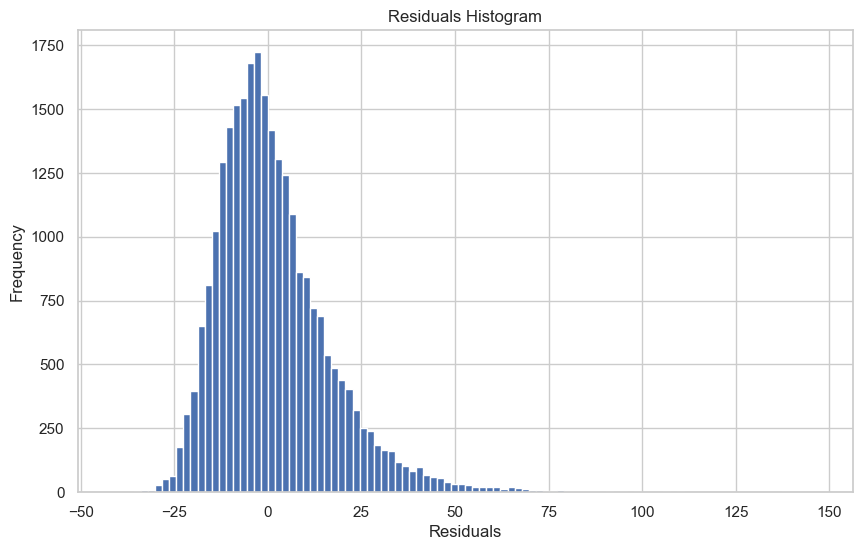

In [30]:
residuals = y_test_o - predictions_o
residuals = residuals.flatten()
residuals.shape
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100)
plt.title("Residuals Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

<b style='padding: 4px 10px 6px 10px;border-radius: 5px;background: #009688;color: #fff;display: inline-block;'>Observations</b>
- We can see that residuals are normally distributed.

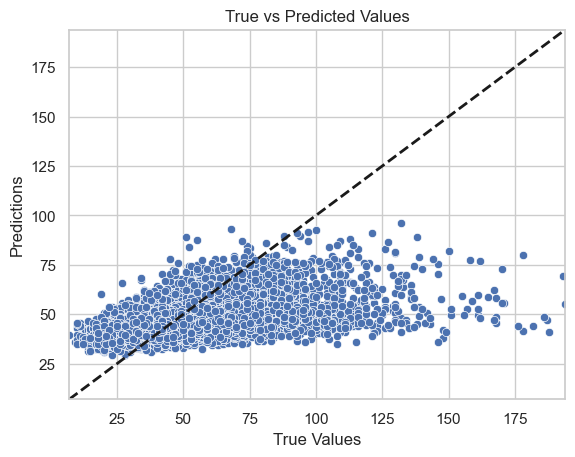

In [31]:
sns.scatterplot(x=y_test_o.flatten(), y=predictions_o.flatten())
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values")
plt.plot([y_test_o.min(), y_test_o.max()], [y_test_o.min(), y_test_o.max()], 'k--', lw=2)
plt.xlim(y_test_o.min(), y_test_o.max())
plt.ylim(y_test_o.min(), y_test_o.max())
plt.show()

<b style='padding: 4px 10px 6px 10px;border-radius: 5px;background: #009688;color: #fff;display: inline-block;'>Observations</b>

- From above plot we can see that model is underperforming on the test set.